# Divisive Clustering from Scratch

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

## 1. Mock Data Generation

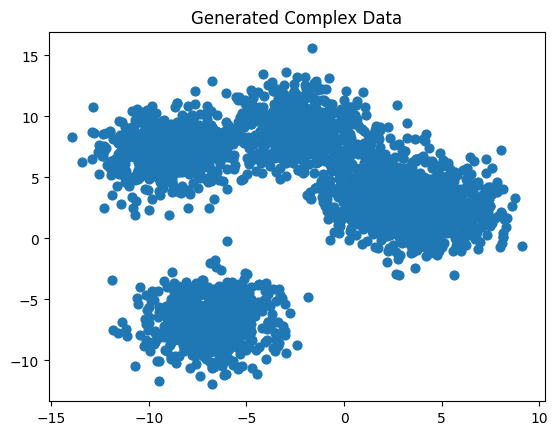

In [14]:
def get_complex_data():
    X, y = make_blobs(n_samples=3000, centers=5, cluster_std=1.7, random_state=42)
    return X, y

X, y_true = get_complex_data()
plt.scatter(X[:, 0], X[:, 1], s=40)
plt.title("Generated Complex Data")
plt.show()

## 2. Implementation

In [ ]:
class DivisiveSimple:
    def __init__(self, clusters=3):
        self.n_clusters = clusters

    def split(self, pts):
        if len(pts) <= 1: return [pts]

        c = pts[np.random.choice(len(pts), 2, replace=False)]
        for _ in range(10):
            lbls = np.array([np.argmin([np.linalg.norm(x-ci) for ci in c]) for x in pts])
            new_c = np.array([pts[lbls==i].mean(axis=0) if np.sum(lbls==i) > 0 else c[i] for i in range(2)])
            if np.allclose(c, new_c): break
            c = new_c
        return [pts[lbls==0], pts[lbls==1]]

    def fit(self, X):
        self.final_clusters = [X]
        while len(self.final_clusters) < self.n_clusters:

            vars = [np.var(c) if len(c) > 1 else 0 for c in self.final_clusters]
            idx = np.argmax(vars)
            target = self.final_clusters.pop(idx)
            self.final_clusters.extend(self.split(target))
        
        self.labels = np.zeros(len(X))
        for cid, cluster in enumerate(self.final_clusters):
            for pt in cluster:
                for orig_idx, orig_pt in enumerate(X):
                    if np.array_equal(pt, orig_pt):
                        self.labels[orig_idx] = cid
        return self

## 3. Training & Measurement

In [16]:
model = DivisiveSimple(clusters=3)
model.fit(X)

score = silhouette_score(X, model.labels)
print(f"Finished clustering. Silhouette Score: {score:.4f}")

Finished clustering. Silhouette Score: 0.3385


## 4. Visualization

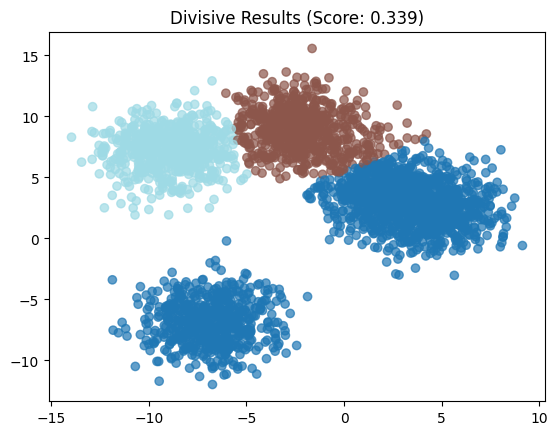

In [17]:
plt.scatter(X[:, 0], X[:, 1], c=model.labels, cmap='tab20', alpha=0.7)
plt.title(f"Divisive Results (Score: {score:.3f})")
plt.show()